In [1]:
import os

os.environ['MUJOCO_GL'] = 'egl'

import mujoco
import mediapy as media
import numpy as np
from tqdm import tqdm
from scipy.spatial.transform import Rotation as R

In [2]:
from g2scene2 import Scene, GRASPNET_SCENE_ROOT, MODEL_DIR, HAND_ASSETS

object_id = 5

XML_PATH = f'scene_{object_id}-2_0000.xml'

s = Scene(scene_dir=GRASPNET_SCENE_ROOT, model_dir=MODEL_DIR, hand_assets=HAND_ASSETS)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
s.save_xml(XML_PATH, obj_indexes=object_id)

Saved → scene_5-2_0000.xml


In [24]:
model = mujoco.MjModel.from_xml_path(XML_PATH)
sim   = mujoco.MjData(model)
mujoco.mj_forward(model, sim)

In [25]:
FINGER_BASE_Z = 0.0584
FINGERTIP_PAD_Z = 0.0445
FINGERTIP_PAD_HALF = 0.0085   # 
FINGERTIP_OFFSET   = FINGER_BASE_Z + FINGERTIP_PAD_Z + FINGERTIP_PAD_HALF 
# FINGERTIP_OFFSET = 0

# ── Simulation constants 
LIFT_HEIGHT   = 0.08   # m above rest z to count as success
HOME_POS      = np.array([0.0, 0.0, 0.6])
HOME_QUAT     = np.array([1.0, 0.0, 0.0, 0.0])  # wxyz

renderer = mujoco.Renderer(model, 480, 640)
cam = mujoco.MjvCamera()
cam.azimuth   = 160
cam.elevation = -30
cam.distance  = 1.0
cam.lookat[:] = [0.0, -0.15, 0.0]

In [26]:
# mocap_id  = model.body("hand_target").mocapid[0]
# hand_qadr = model.joint("hand_freejoint").qposadr[0]

hand_bid = model.body("hand").id

obj_indx = ["obj_{}".format(str(n).zfill(3)) for n in s.get_obj_indexes()]
obj_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, n) for n in obj_indx]

obj_ids = [obj_id for obj_id in obj_ids if obj_id != -1]

In [27]:
obj_ids

[5]

In [28]:
s.get_obj_indexes()

[14, 0, 5, 15, 20, 48, 66, 70, 46]

In [29]:
from graspnetAPI import Grasp
from scipy.spatial.transform import Rotation as R

def grasp_to_world(g : Grasp, align_mat, offset=FINGERTIP_OFFSET):
    t_w = align_mat[:3, :3] @ g.translation + align_mat[:3, 3]

    approach_world = align_mat[:3, :3] @ g.rotation_matrix[:, 0]

    return t_w - approach_world * (offset - g.depth)
    # return t_w - approach_world * offset

def to_rotation(g: Grasp, align_mat):
    r_w = align_mat[:3, :3] @ g.rotation_matrix
    approach = r_w[:, 0]
    binormal = r_w[:, 1]
    minor    = r_w[:, 2]
    r_hand = np.column_stack([-minor, binormal, approach])  # det = +1
    return r_hand

def to_rotation_1(g : Grasp, align_mat):
    r_w = align_mat[:3, :3] @ g.rotation_matrix
    approach = r_w[:, 0]
    spread = r_w[:, 1]
    side = r_w[:, 2]
    r_hand = np.column_stack([side, spread, approach])
    return r_hand

def to_rotation_2(g : Grasp, align_mat):
    r_w = align_mat[:3, :3] @ g.rotation_matrix
    approach = r_w[:, 0]
    spread = r_w[:, 1]
    side = r_w[:, 2]
    r_hand = np.column_stack([spread, side, approach])
    return r_hand

def to_mujoco_quat(g : Grasp, align_mat, rotation_fn : callable = to_rotation):
    r_hand = rotation_fn(g, align_mat)
    q = R.from_matrix(r_hand).as_quat()  # xyzw
    return np.array([q[3], q[0], q[1], q[2]])  # wxyz

def render():
    renderer.update_scene(sim, cam)
    return renderer.render().copy()

def set_hand(pos, quat_wxyz):
    sim.mocap_pos[mocap_id]  = pos
    sim.mocap_quat[mocap_id] = quat_wxyz

def set_hand_pose(model, data, pos, quat_wxyz):
    model.body_pos[hand_bid]  = pos
    model.body_quat[hand_bid] = quat_wxyz
    mujoco.mj_forward(model, data)
    
def teleport_hand(pos, quat_wxyz):
    """Hard-set the freejoint AND the mocap target."""
    sim.qpos[hand_qadr  :hand_qadr+3] = pos
    sim.qpos[hand_qadr+3:hand_qadr+7] = quat_wxyz
    set_hand(pos, quat_wxyz)
    mujoco.mj_forward(model, sim)

def set_gripper_width(width_m):
    """width_m in metres [0, 0.08]"""
    sim.ctrl[0] = float(np.clip((width_m / 0.08) * 255, 0, 255))

def step(n):
    for _ in range(n):
        mujoco.mj_step(model, sim)

Object resting Z positions (world frame):
  obj_014: z = 0.0233 m


Scene after settle (hand at home)

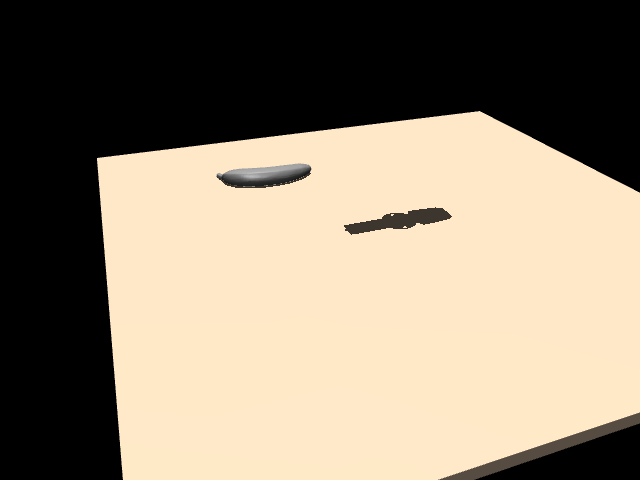

In [31]:
mujoco.mj_resetData(model, sim)
set_hand_pose(model, sim, HOME_POS, HOME_QUAT)
step(500)

Z0_REST = np.array([sim.xpos[oid][2] for oid in obj_ids])
print("Object resting Z positions (world frame):")
for name, z in zip(obj_indx, Z0_REST):
    print(f"  {name}: z = {z:.4f} m")

media.show_image(render(), title="Scene after settle (hand at home)")

In [32]:
from graspnetAPI import GraspGroup

GRASP_POSES = "/home/sbehnam/Project/data/scenes/scene_0000/grasp_group_mine.npy"

gg = GraspGroup(np.load(GRASP_POSES))

gg.sort_by_score()

print(f"Loaded {len(gg)} grasps from GraspNet.")

interested_gg = gg[gg.grasp_group_array[:, -1] == object_id]

print(f"Found {len(interested_gg)} grasps for object ID {object_id}.")

sample_grasp = interested_gg.random_sample(1)[0]

sample_grasp

Loaded 82065 grasps from GraspNet.
Found 14106 grasps for object ID 5.


Grasp: score:0.9000000357627869, width:0.059778597205877304, height:0.019999999552965164, depth:0.029999999329447746, translation:[-0.12488191 -0.00457946  0.47152522]
rotation:
[[-0.5683943   0.79735893 -0.20284624]
 [ 0.51660985  0.53776276  0.66627729]
 [ 0.64034534  0.27391586 -0.71758479]]
object id:5

For testing and comparing to the Point cloud visualization we are testing only on one grasp pose !! 

In [33]:
ONE_SAMPLED_GRASP = "/home/sbehnam/Project/data/scenes/scene_0000/one_banana_grasp.npy"

sample_grasp = GraspGroup(np.load(ONE_SAMPLED_GRASP))[0]

sample_grasp

Grasp: score:0.7000000476837158, width:0.07723478972911835, height:0.019999999552965164, depth:0.009999999776482582, translation:[-0.12182258  0.0191296   0.4786962 ]
rotation:
[[ 0.22006011  0.47901127 -0.84977746]
 [ 0.01666055  0.8691594   0.49425119]
 [ 0.975344   -0.12292271  0.18328674]]
object id:5

In [34]:
print(sample_grasp.translation)

t1 = grasp_to_world(sample_grasp, s.align_mat, offset=FINGERTIP_OFFSET)
print("Sample grasp translation (world frame):", t1)

t2 = grasp_to_world(sample_grasp, s.align_mat, offset=0)
print("Sample grasp translation (world frame):", t2)

t3 = grasp_to_world(sample_grasp, s.camera_pose, offset=FINGERTIP_OFFSET)
print("Sample grasp translation (world frame):", t3)

[-0.12182258  0.0191296   0.4786962 ]
Sample grasp translation (world frame): [-0.14792737 -0.11049986  0.12474035]
Sample grasp translation (world frame): [-0.12450041 -0.13923872  0.01969171]
Sample grasp translation (world frame): [-0.14792737 -0.11049986  0.12474035]


### Sanity check on the Rotation !!

In [35]:
R_hand = to_rotation(sample_grasp, s.align_mat)
print("det(R) =", np.linalg.det(R_hand))                # must be +1.000
print("orthog err =", np.max(np.abs(R_hand.T @ R_hand - np.eye(3))))  # must be ~0

approach_w = s.align_mat[:3,:3] @ sample_grasp.rotation_matrix[:,0]
print("approach_world:", approach_w)                    # z should be ≈ -0.94
print("hand +Z in world:", R_hand[:,2])                 # MUST equal approach_w

det(R) = 0.9999999004471816
orthog err = 1.4936995640368878e-07
approach_world: [ 0.21029583 -0.25797894 -0.94298594]
hand +Z in world: [ 0.21029583 -0.25797894 -0.94298594]


Translation (world frame): [-0.14792737 -0.11049986  0.12474035]
Rotation (world frame): [0.15465074 0.94966681 0.26386726 0.06775076]


telepoted to the grasp pose

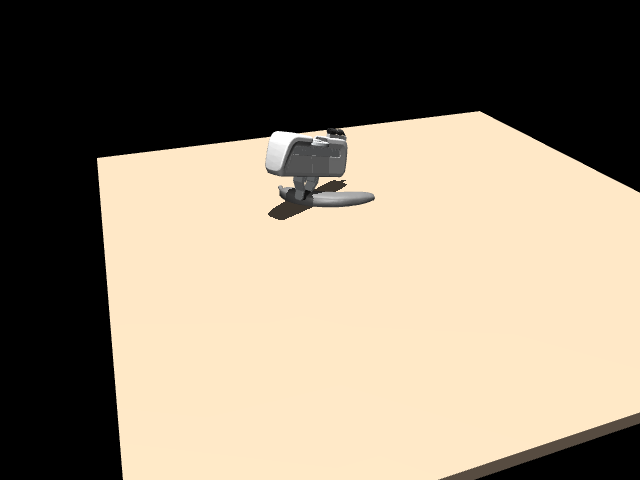

In [36]:
translation = grasp_to_world(sample_grasp, s.align_mat, offset=FINGERTIP_OFFSET)
rotation = to_mujoco_quat(sample_grasp, s.align_mat, rotation_fn=to_rotation)

print("Translation (world frame):", translation)
print("Rotation (world frame):", rotation)

mujoco.mj_resetData(model, sim)
set_gripper_width(sample_grasp.width)
set_hand_pose(model, sim, translation, rotation)
frame = render()
media.show_image(frame, title="telepoted to the grasp pose")

Translation (world frame): [-0.14792737 -0.11049986  0.12474035]
Rotation (world frame): [0.15465074 0.94966681 0.26386726 0.06775076]


telepoted to the grasp pose

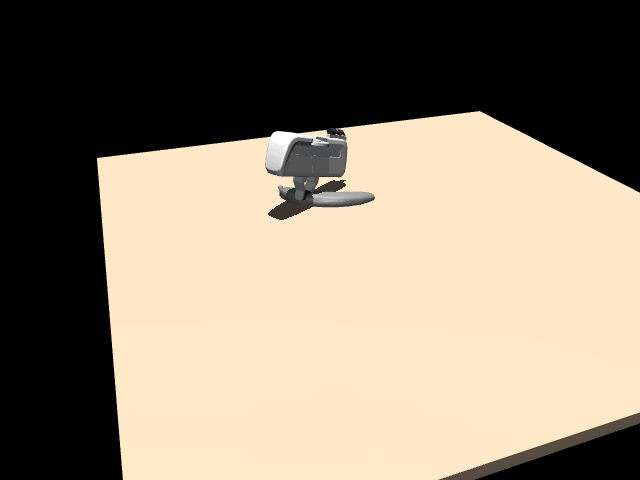

In [ ]:
# translation = grasp_to_world(sample_grasp, s.align_mat, offset=FINGERTIP_OFFSET)
# rotation = to_mujoco_quat(sample_grasp, s.align_mat, rotation_fn=to_rotation)

# print("Translation (world frame):", translation)
# print("Rotation (world frame):", rotation)

# mujoco.mj_resetData(model, sim)
# set_gripper_width(sample_grasp.width)
# teleport_hand(translation, rotation)
# frame = render()
# media.show_image(frame, title="telepoted to the grasp pose")

### ---

In [37]:
# Orbit the camera around the table to inspect the gripper from all angles
orbit_cam = mujoco.MjvCamera()
orbit_cam.elevation = -25
orbit_cam.distance  = 1.1
orbit_cam.lookat[:] = [0.0, -0.15, 0.05]

N_FRAMES = 120     # ~3 s @ 30 fps -> 4 deg/frame
FPS      = 30
frames = []
for i in range(N_FRAMES):
    orbit_cam.azimuth = (360.0 * i / N_FRAMES) % 360.0
    renderer.update_scene(sim, orbit_cam)
    frames.append(renderer.render().copy())

media.show_video(frames, fps=FPS, loop=True)

This browser does not support the video tag.


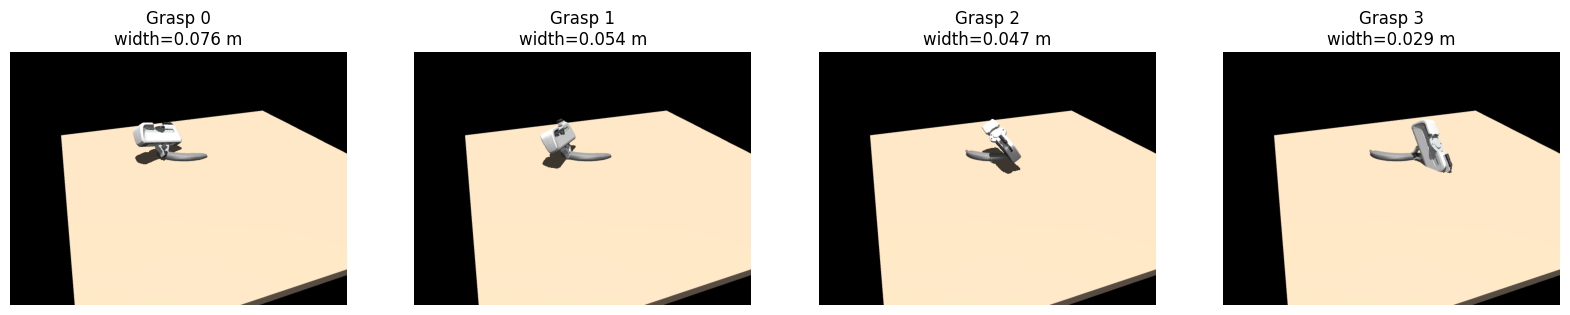

In [ ]:
import matplotlib.pyplot as plt

some_sample_grasp = GraspGroup(np.load("/home/sbehnam/Project/data/scenes/scene_0000/some_banana_grasp.npy"))

some_sample_grasp


fig, axes = plt.subplots(1, 4, figsize=(20, 5))

mujoco.mj_resetData(model, sim)

for i in range(4):
    g = some_sample_grasp[i]
    t = grasp_to_world(g, s.align_mat, offset=FINGERTIP_OFFSET)
    r = to_mujoco_quat(g, s.align_mat, rotation_fn=to_rotation)
    set_gripper_width(g.width)
    teleport_hand(t, r)
    # step(10) ! If I do this, then the gripper falls onto the object and the renderings look weird. Why? !! 
    renderer.update_scene(sim, cam)
    axes[i].imshow(renderer.render())
    axes[i].set_title(f"Grasp {i}\nwidth={g.width:.3f} m")
    axes[i].axis('off')
plt.show()